# CS630 - Homework 2 | Option B — Independent classification challenge

- Name: `Ja'farbek Yusupov`
- Student ID: `240057`


Task: predict whether a wine comes from cultivar 0 or cultivar 1 using two chemical measurements, `color_intensity` and `proline`. The workflow is

$$
\text{inspect} \rightarrow \text{choose }X,y \rightarrow \text{split}
\rightarrow \text{fit} \rightarrow \text{predict} \rightarrow
\text{evaluate} \rightarrow \text{diagnose}
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_wine
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.set_printoptions(precision=3, suppress=True)

print("Environment ready")

Environment ready


### dataset

In [2]:
wine = load_wine(as_frame=True)

# Keep only two classes to create a binary-classification problem
binary_mask = wine.target.isin([0, 1])

# Use two features so the decision boundary can be visualized
X_challenge = wine.data.loc[
    binary_mask,
    ["color_intensity", "proline"]
].to_numpy()

y_challenge_zero_one = wine.target.loc[
    binary_mask
].to_numpy()

print("Challenge dataset loaded.")

Challenge dataset loaded.


## 1. Inspect the data

In [3]:
feature_names = ["color_intensity", "proline"]
class_names = ("Cultivar 0", "Cultivar 1")

print("x shape:", X_challenge.shape)
print("y shape:", y_challenge_zero_one.shape)
print("class counts:")
print(
    pd.Series(y_challenge_zero_one)
    .value_counts()
    .sort_index() 
    .rename(index={0: class_names[0], 1: class_names[1]})
)

display(
    pd.DataFrame(X_challenge, columns=feature_names)
    .assign(cultivar=y_challenge_zero_one)
    .groupby("cultivar")
    .describe()
    .T
    .round(2)
)

x shape: (130, 2)
y shape: (130,)
class counts:
Cultivar 0    59
Cultivar 1    71
Name: count, dtype: int64


cultivar                     0       1
color_intensity count    59.00   71.00
                mean      5.53    3.09
                std       1.24    0.92
                min       3.52    1.28
                25%       4.55    2.54
                50%       5.40    2.90
                75%       6.22    3.40
                max       8.90    6.00
proline         count    59.00   71.00
                mean   1115.71  519.51
                std     221.52  157.21
                min     680.00  278.00
                25%     987.50  406.50
                50%    1095.00  495.00
                75%    1280.00  625.00
                max    1680.00  985.00

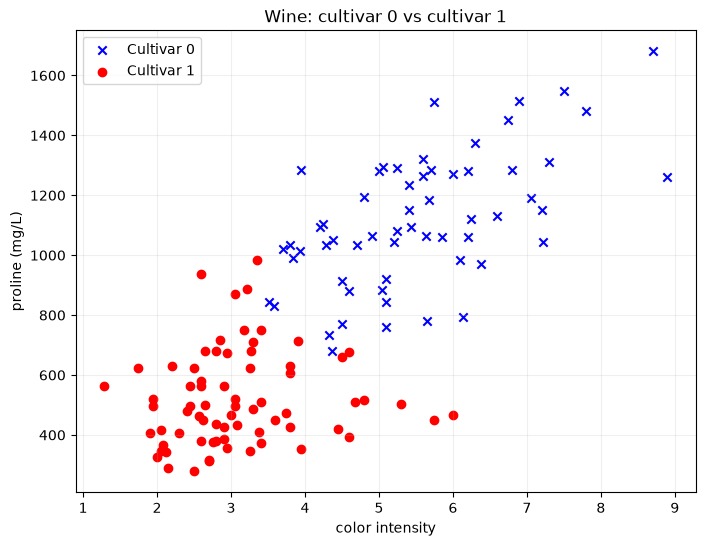

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_challenge[y_challenge_zero_one == 0, 0],
    X_challenge[y_challenge_zero_one == 0, 1],
    color="blue",
    marker="x",
    label=class_names[0],
)
plt.scatter(
    X_challenge[y_challenge_zero_one == 1, 0],
    X_challenge[y_challenge_zero_one == 1, 1],
    color="red",
    marker="o",
    label=class_names[1],
)

plt.xlabel("color intensity")
plt.ylabel("proline (mg/L)")
plt.title("Wine: cultivar 0 vs cultivar 1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

**Is a linear boundary suitable?** 

Mostly yes. The 130 samples are fairly balanced (59 vs 71). Cultivar 0 sits in the upper right of the plot: high proline (median about 1095 mg/L, never below 680) and higher color intensity (median about 5.4). Cultivar 1 sits in the lower left: low proline (median about 495) and low color intensity (median about 2.9). Straight line running from upper left to lower right separates *almost* all of the points.

However classes are not perfectly linearly separable. A few cultivar 1 wines have unusually high proline (around 870–985 mg/L) or high color intensity (around 4.5–6.0), and they reach into the cultivar 0 region. Linear classifier should reach high accuracy, but the perceptron may never finish an epoch with 0 mistakes.

The feature scales also differ a lot. Proline ranges from about 280 to 1700, while color intensity ranges from about 1 to 9. Without standardization, proline would dominate both the score and the perceptron updates.

## 2. Prepare the data

In [6]:
# convert labels from 0/1 to -1/+1 (cultivar 0 -> -1, cultivar 1 -> +1)
y_challenge = np.where(y_challenge_zero_one == 0, -1, 1)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_challenge,
    y_challenge,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_challenge,
)

# scaler to fit only on training data, then applied onto both sets
wine_scaler = StandardScaler()
Xw_train_scaled = wine_scaler.fit_transform(Xw_train)
Xw_test_scaled = wine_scaler.transform(Xw_test)

print("training shape:", Xw_train.shape, "| class counts:", pd.Series(yw_train).value_counts().sort_index().to_dict())
print("test shape: ", Xw_test.shape, "| class counts:", pd.Series(yw_test).value_counts().sort_index().to_dict())
print("scaler mean (train):", wine_scaler.mean_)
print("scaler std (train):", wine_scaler.scale_)

training shape: (97, 2) | class counts: {-1: 44, 1: 53}
test shape:  (33, 2) | class counts: {-1: 15, 1: 18}
scaler mean (train): [  4.121 791.701]
scaler std (train): [  1.639 337.628]


## 3. Scikit-learn perceptron

In [7]:
sk_wine = Perceptron(
    max_iter=1000,
    tol=1e-3,
    eta0=0.1,
    random_state=RANDOM_STATE,
)
sk_wine.fit(Xw_train_scaled, yw_train)

sk_wine_predictions = sk_wine.predict(Xw_test_scaled)
sk_wine_accuracy = accuracy_score(yw_test, sk_wine_predictions)
sk_wine_train_accuracy = accuracy_score(yw_train, sk_wine.predict(Xw_train_scaled))

print("scikit-learn weights: ", sk_wine.coef_[0])
print("scikit-learn intercept: ", sk_wine.intercept_[0])
print("scikit-learn epochs: ", sk_wine.n_iter_)
print("training accuracy: ", round(sk_wine_train_accuracy, 3))
print("test accuracy: ", round(sk_wine_accuracy, 3))

scikit-learn weights:  [-0.223 -0.283]
scikit-learn intercept:  0.0
scikit-learn epochs:  11
training accuracy:  0.948
test accuracy:  1.0


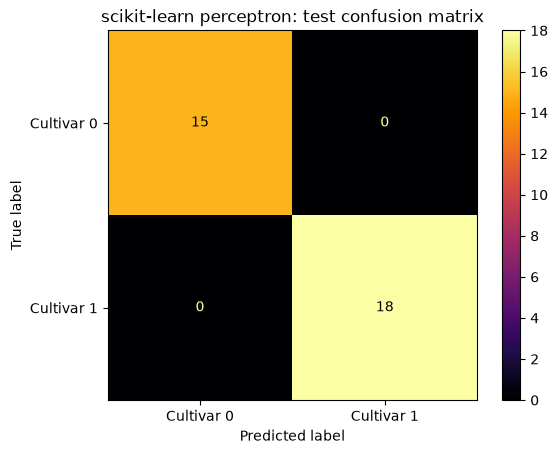

In [12]:
ConfusionMatrixDisplay.from_predictions(
    yw_test,
    sk_wine_predictions,
    labels=[-1, 1],
    display_labels=class_names,
    cmap="inferno",
)
plt.title("scikit-learn perceptron: test confusion matrix")
plt.show()

Perceptron is trained on standartized features. In order to draw its boundary on the original axes we need to convert the parameters back. 

so if $z_j = (x_j-\mu_j)/\sigma_j$, then

$$
\mathbf{w}^T\mathbf{z}+b = \sum_j \frac{w_j}{\sigma_j}x_j + \Big(b-\sum_j \frac{w_j\mu_j}{\sigma_j}\Big).
$$

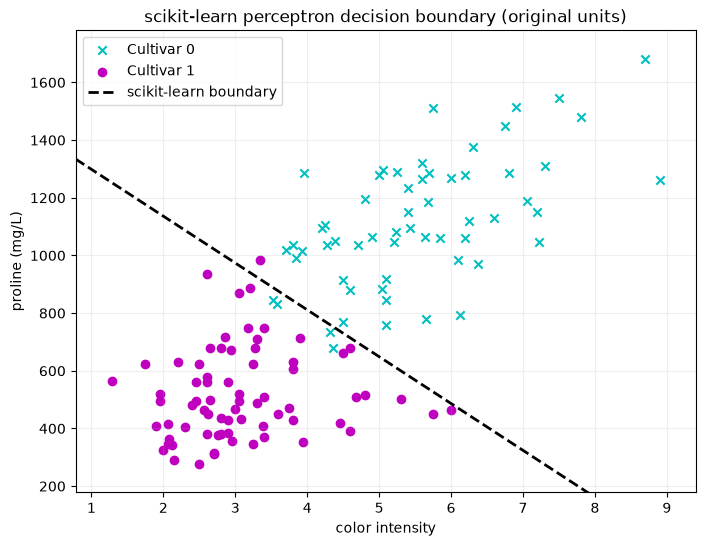

In [15]:
def to_original_units(w, b, scaler):
    w_original = w / scaler.scale_
    b_original = b - np.sum(w * scaler.mean_ / scaler.scale_)
    return w_original, b_original


def plot_wine_boundary(X, y, boundaries, title):
    """boundaries: list of (w, b, label, color, linestyle) in standardized units"""
    x1_values = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)

    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color="c", marker="x", label=class_names[0])
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color="m", marker="o", label=class_names[1])

    for w, b, label, color, linestyle in boundaries:
        (w1, w2), b0 = to_original_units(w, b, wine_scaler)
        if not np.isclose(w2, 0):
            plt.plot(
                x1_values, 
                -(w1*x1_values + b0)/w2,
                color=color, 
                linestyle=linestyle,
                linewidth=2,
                label=label
            )
        else:
            plt.axvline(
                -b0/w1,
                color=color, 
                linestyle=linestyle, 
                linewidth=2, 
                label=label
            )

    plt.xlim(x1_values[0], x1_values[-1])
    plt.ylim(X[:,1].min() - 100, X[:,1].max() + 100)
    plt.xlabel("color intensity")
    plt.ylabel("proline (mg/L)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# fitted on training split only; all 130 samples shown for context
plot_wine_boundary(
    X_challenge,
    y_challenge,
    [(sk_wine.coef_[0], sk_wine.intercept_[0], "scikit-learn boundary", "black", "--")],
    "scikit-learn perceptron decision boundary (original units)",
)

## 4. Perceptron from scratch

For each training observation: compute $s_i=\mathbf{w}^T\mathbf{x}_i+b$. If $y_i s_i \le 0$, update

$$
\mathbf{w}\leftarrow\mathbf{w}+\eta\,y_i\mathbf{x}_i,\qquad b\leftarrow b+\eta\,y_i .
$$

Training stops as soon as an epoch makes **zero updates**. Because convergence is guaranteed only for linearly separable data, there is also a safety cap of `max_epochs=1000`, which matches scikit-learn's `max_iter`.

In [16]:
def train_perceptron(X, y, learning_rate=0.1, max_epochs=1000):
    w = np.zeros(X.shape[1])
    b = 0.0
    updates_per_epoch = []

    for epoch in range(max_epochs):
        epoch_updates = 0

        for xi, yi in zip(X, y):
            score = np.dot(w, xi) + b

            if yi * score <= 0:
                w = w + learning_rate * yi * xi
                b = b + learning_rate * yi
                epoch_updates += 1

        updates_per_epoch.append(epoch_updates)

        if epoch_updates == 0: break

    converged = updates_per_epoch[-1] == 0
    return w, b, np.array(updates_per_epoch), converged

def predict_perceptron(X, w, b):
    scores = X @ w + b
    return np.where(scores >= 0, 1, -1)

In [17]:
w_manual, b_manual, update_history, manual_converged = train_perceptron(
    Xw_train_scaled,
    yw_train,
    learning_rate=0.1,
    max_epochs=1000,
)

manual_predictions = predict_perceptron(Xw_test_scaled, w_manual, b_manual)
manual_accuracy = accuracy_score(yw_test, manual_predictions)
manual_train_accuracy = accuracy_score(yw_train, predict_perceptron(Xw_train_scaled, w_manual, b_manual))

print("manual weights: ", np.round(w_manual, 3))
print("manual intercept: ", round(b_manual, 3))
print("epochs run: ", len(update_history))
print("total updates: ", update_history.sum())
print("converged: ", manual_converged)
print("updates, first 10 epochs: ", update_history[:10])
print("updates, last 10 epochs: ", update_history[-10:])
print("min / max updates in an epoch: ", update_history.min(), "/", update_history.max())
print("training accuracy: ", round(manual_train_accuracy, 3))
print("test accuracy: ", round(manual_accuracy, 3))

manual weights:  [-0.212 -0.216]
manual intercept:  0.0
epochs run:  1000
total updates:  8002
converged:  False
updates, first 10 epochs:  [10  9  7  9  7  9  7  9  7  8]
updates, last 10 epochs:  [7 8 9 8 7 8 9 7 9 7]
min / max updates in an epoch:  7 / 10
training accuracy:  0.948
test accuracy:  0.97


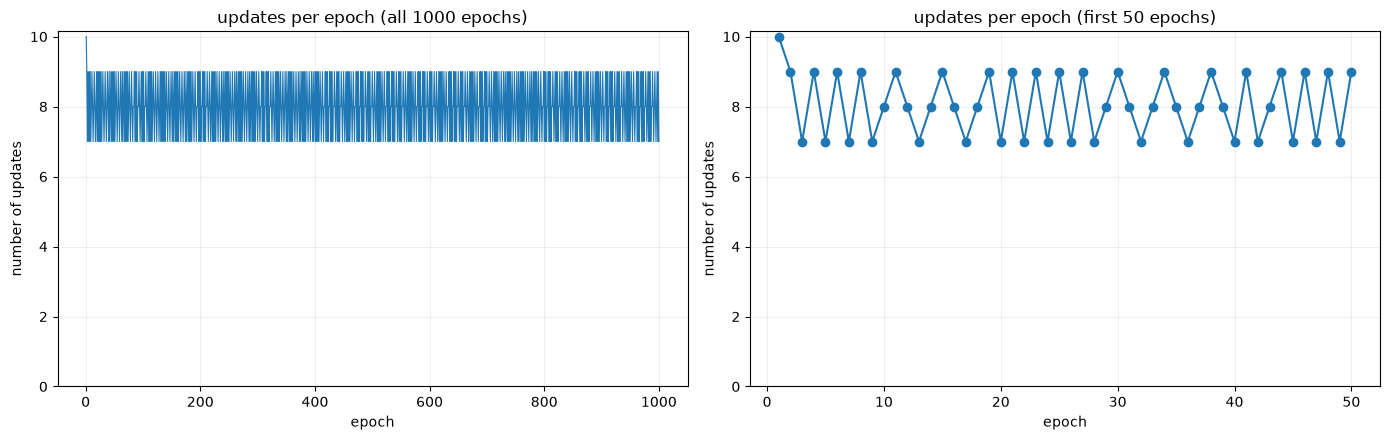

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

epochs_axis = np.arange(1, len(update_history)+1)
axes[0].plot(epochs_axis, update_history, linewidth=0.8)
axes[0].set_title(f"updates per epoch (all {len(update_history)} epochs)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("number of updates")
axes[0].set_ylim(bottom=0)
axes[0].grid(alpha=0.2)

zoom = min(50, len(update_history))
axes[1].plot(epochs_axis[:zoom], update_history[:zoom], marker="o")
axes[1].set_title(f"updates per epoch (first {zoom} epochs)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("number of updates")
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

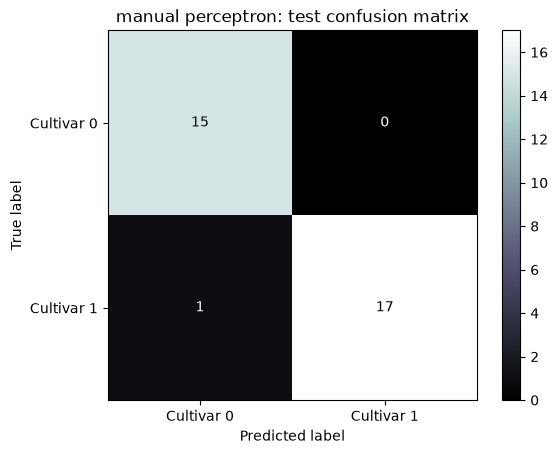

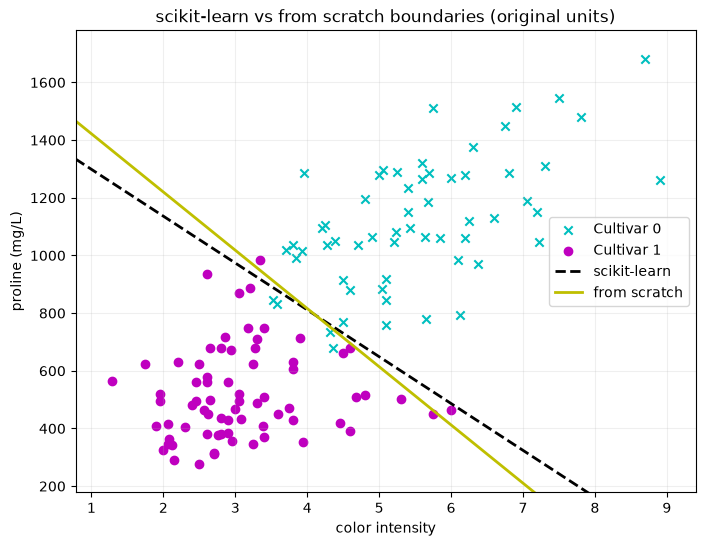

In [28]:
ConfusionMatrixDisplay.from_predictions(
    yw_test,
    manual_predictions,
    labels=[-1, 1],
    display_labels=class_names,
    cmap="bone",
)
plt.title("manual perceptron: test confusion matrix")
plt.show()

plot_wine_boundary(
    X_challenge,
    y_challenge,
    [
        (sk_wine.coef_[0], sk_wine.intercept_[0], "scikit-learn", "black", "--"),
        (w_manual, b_manual, "from scratch", "y", "-"),
    ],
    "scikit-learn vs from scratch boundaries (original units)",
)

In [30]:
comparison = pd.DataFrame({
    "implementation": ["scikit-learn", "from scratch"],
    "w (color_intensity)": [sk_wine.coef_[0][0], w_manual[0]],
    "w (proline)": [sk_wine.coef_[0][1], w_manual[1]],
    "b": [sk_wine.intercept_[0], b_manual],
    "epochs": [sk_wine.n_iter_, len(update_history)],
    "train accuracy": [sk_wine_train_accuracy, manual_train_accuracy],
    "test accuracy": [sk_wine_accuracy, manual_accuracy],
}).round(3)

display(comparison)

print("scikit-learn confusion matrix (rows = true -1/+1):")
print(confusion_matrix(yw_test, sk_wine_predictions, labels=[-1, 1]))
print("manual confusion matrix (rows = true -1/+1):")
print(confusion_matrix(yw_test, manual_predictions, labels=[-1, 1]))

,implementation,w (color_intensity),w (proline),b,epochs,train accuracy,test accuracy
0,scikit-learn,-0.223,-0.283,0.0,11,0.948,1.00
1,from scratch,-0.212,-0.216,0.0,1000,0.948,0.97


scikit-learn confusion matrix (rows = true -1/+1):
[[15  0]
 [ 0 18]]
manual confusion matrix (rows = true -1/+1):
[[15  0]
 [ 1 17]]


## 5. Interpretation

**Coefficients.** 
- Both models learned the same kind of rule. Both weights are negative, so high color intensity and high proline push the score toward −1 (cultivar 0).
- The weight vectors point in nearly the same direction: sklearn about (−0.22, −0.28) vs manual about (−0.21, −0.22), both passing through the origin (intercept $= 0$) due to standardized features.
- But still exact numbers differ, because the perceptron has no single "correct" solution. Its result depends on the order of the training examples, the stopping rule and the epoch at which training stops. Scikit-learn also shuffles the data each epoch by default, while the manual version visits the samples in a fixed order. When the data cannot be separated, the parameters never settle, so stopping at a different epoch gives a slightly different line.

**Convergence.** 
- Manual model: failed to converge, running all 1,000 epochs with continuous updates (7–10 per epoch). Perceptron convergence theorem dictates that overlapping, non linearly separable data forces perpetual boundary oscillations.
- Sklearn model: stopped early at 11 epochs, *but **not** because it achieved convergence* - it stopped based on its tolerance rule (`tol=1e-3` over `n_iter_no_change=5`)
- Both models finish with the same 94.8% training accuracy, which means 5 of the 97 training points are misclassified.

**Accuracy.** 
- On the 33 test wines, sklearn scored 100% and the manual model scored 97.0%. The difference is exactly one wine, a cultivar 1 sample that lies close to the border.
- With only 33 test samples, one prediction is worth 3 percentage points, so the gap reflects where each line happened to stop *rather than a meaningful difference in quality.*
- Lower training accuracy (`94.8%`) is the better indication of how well a line can do on this data, as the perfect test score likely reflects favorable sampling in this specific train-test split.

**Confusion Matrix insights.** 
- It shows which classes produce the errors:
  - Sklearn had zero test errors (`15/15` and `18/18`).
  - Manual model made a single false Cultivar 0 prediction (a Cultivar 1 sample with unusually high proline/color intensity), matching the observed scatter plot overlap.

**Summary.** 

Linear perceptron is a good model for this pair of features: it reaches about `95–100%` accuracy. Nevertheless, there is still a slight overlap between classes, so the plain perceptron cannot reach zero training errors and thus it fails to converge, and without convergence the model relies entirely on its stopping rule to freeze the final boundary.